### 0. Content page

1. Load packages and data
2. Helper functions
3. Rebuild long / short / net returns
4. Core performance table
5. Cumulative performance plot: Long / Short / Net
6. Drawdown plot
7. Return histogram
8. Long vs short correlation and descriptive stats
9. Signal diagnostics: E/P and P/B
10. Universe size over time
11. Portfolio breadth over time
12. Long vs short composition
13. Benchmark comparison vs S&P 500
14. Turnover
15. A compact text summary cell for every model

### 1. Load packages and data

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
RESULT_DIR = "../tables/modified_ff_top1000_market_cap_top50_long_top50_short/"

In [3]:
portfolio_returns = pd.read_csv(f"{RESULT_DIR}/portfolio_returns.csv")
asset_returns = pd.read_csv(f"{RESULT_DIR}/asset_returns.csv")
weights_at_E = pd.read_csv(f"{RESULT_DIR}/weights_at_E.csv")
signals_at_T = pd.read_csv(f"{RESULT_DIR}/signals_at_T.csv")

# optional
try:
    portfolio_membership_at_T = pd.read_csv(f"{RESULT_DIR}/portfolio_membership_at_T.csv")
except FileNotFoundError:
    portfolio_membership_at_T = None

In [4]:
# parse dates
for c in ["signal_date", "execution_date", "next_execution_date"]:
    if c in portfolio_returns.columns:
        portfolio_returns[c] = pd.to_datetime(portfolio_returns[c])

for c in ["signal_date", "execution_date", "next_execution_date", "actual_exit_date"]:
    if c in asset_returns.columns:
        asset_returns[c] = pd.to_datetime(asset_returns[c])

for c in ["signal_date", "execution_date"]:
    if c in weights_at_E.columns:
        weights_at_E[c] = pd.to_datetime(weights_at_E[c])

if "signal_date" in signals_at_T.columns:
    signals_at_T["signal_date"] = pd.to_datetime(signals_at_T["signal_date"])

if portfolio_membership_at_T is not None:
    for c in ["signal_date", "execution_date"]:
        if c in portfolio_membership_at_T.columns:
            portfolio_membership_at_T[c] = pd.to_datetime(portfolio_membership_at_T[c])

In [5]:
print("portfolio_returns:", portfolio_returns.shape)
print("asset_returns:", asset_returns.shape)
print("weights_at_E:", weights_at_E.shape)
print("signals_at_T:", signals_at_T.shape)
if portfolio_membership_at_T is not None:
    print("portfolio_membership_at_T:", portfolio_membership_at_T.shape)

portfolio_returns: (238, 4)
asset_returns: (23797, 11)
weights_at_E: (23797, 23)
signals_at_T: (237647, 19)
portfolio_membership_at_T: (23797, 22)


### 2. Helper functions

In [6]:
def annualized_sharpe(monthly_returns: pd.Series) -> float:
    monthly_returns = monthly_returns.dropna()
    if monthly_returns.std() == 0:
        return np.nan
    return monthly_returns.mean() / monthly_returns.std() * np.sqrt(12)

def max_drawdown(return_series: pd.Series) -> float:
    cum = (1 + return_series.fillna(0)).cumprod()
    roll_max = cum.cummax()
    drawdown = cum / roll_max - 1
    return drawdown.min()

def performance_summary(return_series: pd.Series) -> pd.Series:
    return pd.Series({
        "mean_monthly": return_series.mean(),
        "vol_monthly": return_series.std(),
        "ann_sharpe": annualized_sharpe(return_series),
        "positive_month_pct": (return_series > 0).mean(),
        "max_drawdown": max_drawdown(return_series),
    })

### 3. Rebuild long / short / net returns

In [7]:
ls_monthly = (
    asset_returns
    .groupby(["signal_date", "execution_date", "next_execution_date", "side"], as_index=False)["weighted_return"]
    .sum()
    .pivot(
        index=["signal_date", "execution_date", "next_execution_date"],
        columns="side",
        values="weighted_return"
    )
    .reset_index()
)

ls_monthly.columns.name = None

for col in ["long", "short"]:
    if col not in ls_monthly.columns:
        ls_monthly[col] = 0.0

ls_monthly = ls_monthly.rename(columns={
    "long": "long_return",
    "short": "short_return"
})

ls_monthly["portfolio_return_rebuilt"] = (
    ls_monthly["long_return"] + ls_monthly["short_return"]
)

ls_monthly.head()

,signal_date,execution_date,next_execution_date,long_return,short_return,portfolio_return_rebuilt
0,2006-02-28,2006-03-01,2006-04-03,0.030340,-0.012107,0.018233
1,2006-03-31,2006-04-03,2006-05-01,0.005906,0.006661,0.012567
2,2006-04-28,2006-05-01,2006-06-01,-0.007266,0.015287,0.008021
3,2006-05-31,2006-06-01,2006-07-03,-0.003474,0.011763,0.008289
4,2006-06-30,2006-07-03,2006-08-01,-0.014630,0.017180,0.002550


In [8]:
# optional consistency check against saved portfolio_returns.csv
check = portfolio_returns.merge(
    ls_monthly,
    on=["signal_date", "execution_date", "next_execution_date"],
    how="inner"
)

check["diff"] = check["portfolio_return"] - check["portfolio_return_rebuilt"]

print("max abs diff:", check["diff"].abs().max())
print("nonzero diff rows:", (check["diff"].abs() > 1e-12).sum())

max abs diff: 2.55351295663786e-15
nonzero diff rows: 0


### 4. Core performance table

In [9]:
summary_table = pd.DataFrame({
    "long_leg": performance_summary(ls_monthly["long_return"]),
    "short_leg": performance_summary(ls_monthly["short_return"]),
    "net_portfolio": performance_summary(ls_monthly["portfolio_return_rebuilt"]),
}).T

summary_table

,mean_monthly,vol_monthly,ann_sharpe,positive_month_pct,max_drawdown
long_leg,0.004536,0.034561,0.454618,0.588235,-0.370848
short_leg,-0.006605,0.052012,-0.439930,0.441176,-0.900038
net_portfolio,-0.002070,0.047981,-0.149435,0.508403,-0.671288


### 5. Cumulative performance plot: Long / Short / Net

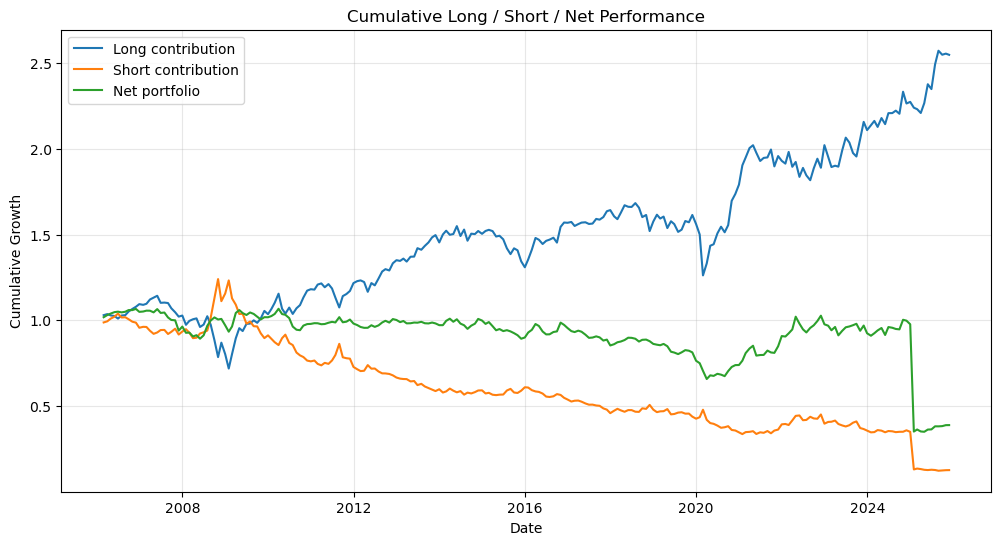

In [10]:
plot_df = ls_monthly.sort_values("signal_date").copy()

plot_df["cum_long"] = (1 + plot_df["long_return"]).cumprod()
plot_df["cum_short"] = (1 + plot_df["short_return"]).cumprod()
plot_df["cum_net"] = (1 + plot_df["portfolio_return_rebuilt"]).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(plot_df["signal_date"], plot_df["cum_long"], label="Long contribution")
plt.plot(plot_df["signal_date"], plot_df["cum_short"], label="Short contribution")
plt.plot(plot_df["signal_date"], plot_df["cum_net"], label="Net portfolio")
plt.title("Cumulative Long / Short / Net Performance")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 6. Drawdown plot

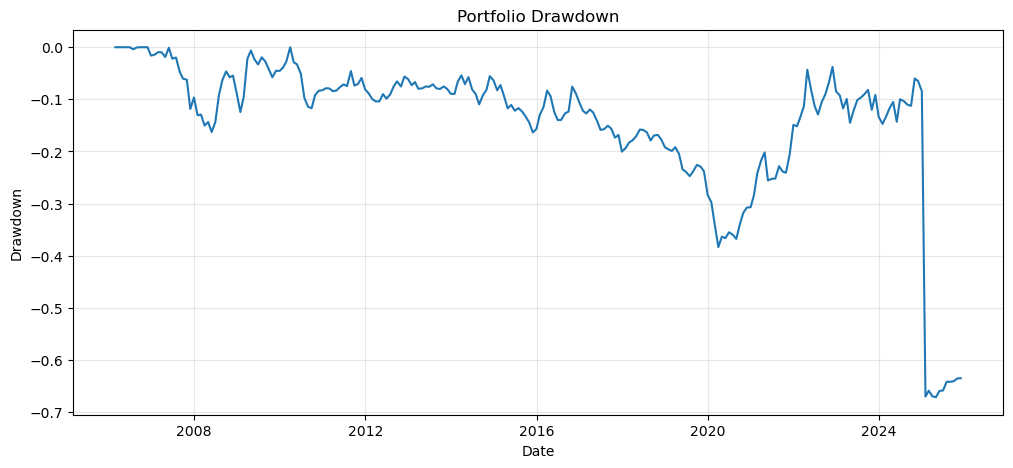

In [11]:
drawdown_df = plot_df[["signal_date", "portfolio_return_rebuilt"]].copy()
drawdown_df["cum"] = (1 + drawdown_df["portfolio_return_rebuilt"]).cumprod()
drawdown_df["roll_max"] = drawdown_df["cum"].cummax()
drawdown_df["drawdown"] = drawdown_df["cum"] / drawdown_df["roll_max"] - 1

plt.figure(figsize=(12, 5))
plt.plot(drawdown_df["signal_date"], drawdown_df["drawdown"])
plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True, alpha=0.3)
plt.show()

### 7. Return histogram

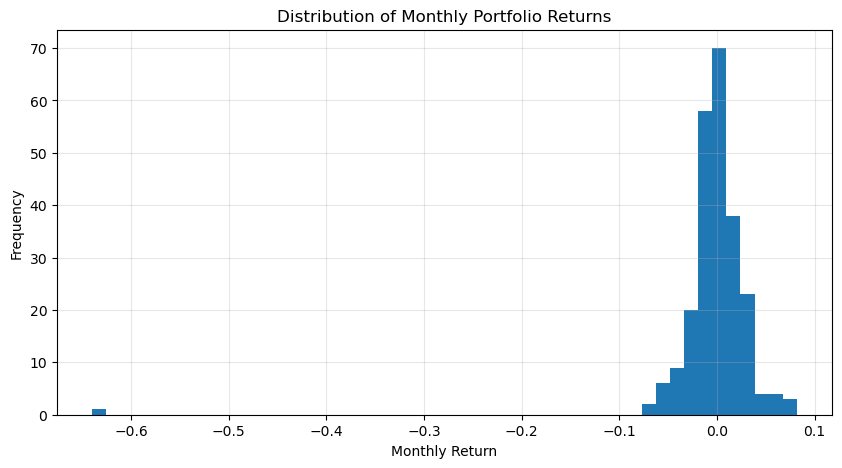

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(ls_monthly["portfolio_return_rebuilt"], bins=50)
plt.title("Distribution of Monthly Portfolio Returns")
plt.xlabel("Monthly Return")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

### 8. Long vs short correlation and descriptive stats

In [13]:
corr_ls = ls_monthly["long_return"].corr(ls_monthly["short_return"])
print("Correlation between long and short contributions:", corr_ls)

Correlation between long and short contributions: -0.44437118626186367


In [14]:
ls_monthly[["long_return", "short_return", "portfolio_return_rebuilt"]].describe()

,long_return,short_return,portfolio_return_rebuilt
count,238.000000,238.000000,238.000000
mean,0.004536,-0.006605,-0.002070
std,0.034561,0.052012,0.047981
min,-0.158801,-0.624813,-0.639698
25%,-0.014579,-0.021950,-0.012858
50%,0.005652,-0.004427,0.000557
75%,0.025656,0.013528,0.013973
max,0.116958,0.111310,0.081800


In [15]:
# gross-normalized leg returns assuming 0.5 gross long / 0.5 gross short
ls_monthly["long_book_raw_return"] = ls_monthly["long_return"] / 0.5
ls_monthly["short_book_pnl_per_gross"] = ls_monthly["short_return"] / 0.5

ls_monthly[[
    "long_return",
    "short_return",
    "long_book_raw_return",
    "short_book_pnl_per_gross"
]].describe()

,long_return,short_return,long_book_raw_return,short_book_pnl_per_gross
count,238.000000,238.000000,238.000000,238.000000
mean,0.004536,-0.006605,0.009071,-0.013211
std,0.034561,0.052012,0.069121,0.104025
min,-0.158801,-0.624813,-0.317601,-1.249627
25%,-0.014579,-0.021950,-0.029158,-0.043901
50%,0.005652,-0.004427,0.011304,-0.008855
75%,0.025656,0.013528,0.051312,0.027056
max,0.116958,0.111310,0.233915,0.222620


### 9. Signal diagnostics: E/P and P/B

In [16]:
weights_at_E["mom_1m"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    23797.000000
mean         0.017439
std          0.140017
min         -0.966172
1%          -0.338751
5%          -0.189479
50%          0.009965
95%          0.236117
99%          0.409915
max          1.754735
Name: mom_1m, dtype: float64

In [17]:
weights_at_E["pb"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    2.379700e+04
mean     8.771629e+03
std      3.308745e+05
min      1.849899e-04
1%       9.638095e-02
5%       6.164165e-01
50%      2.987629e+00
95%      2.178105e+02
99%      1.971225e+04
max      3.773980e+07
Name: pb, dtype: float64

In [18]:
weights_at_E["mom_1m"].sort_values(ascending=False).head(10)

4203     1.754735
20997    1.590062
3948     1.508475
17712    1.479310
3819     1.463808
3512     1.175824
3808     1.125848
17001    1.063649
3403     1.056156
3405     1.023665
Name: mom_1m, dtype: float64

In [19]:
weights_at_E["pb"].sort_values(ascending=False).head(10)

15291    3.773980e+07
9497     1.696346e+07
9097     1.257912e+07
9297     1.243732e+07
10297    1.069423e+07
10096    9.003178e+06
8797     7.853785e+06
10196    7.722391e+06
9796     7.436894e+06
8896     7.342970e+06
Name: pb, dtype: float64

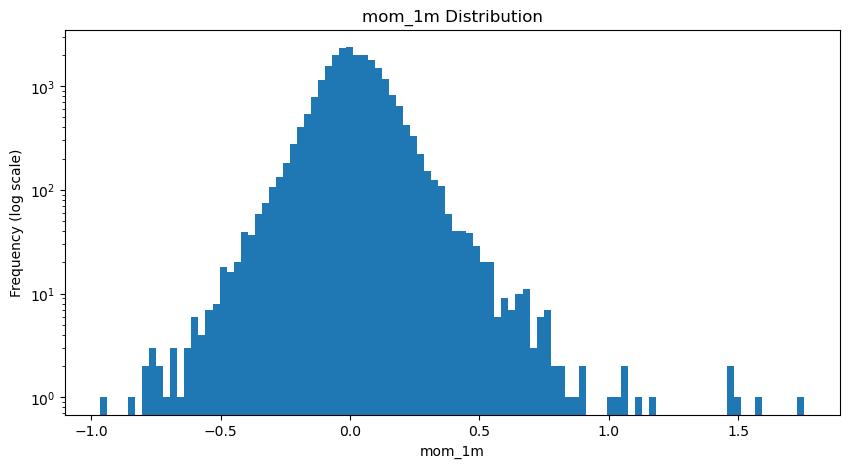

In [20]:
plt.figure(figsize=(10, 5))
plt.hist(weights_at_E["mom_1m"], bins=100)
plt.yscale("log")
plt.title("mom_1m Distribution")
plt.xlabel("mom_1m")
plt.ylabel("Frequency (log scale)")
plt.show()

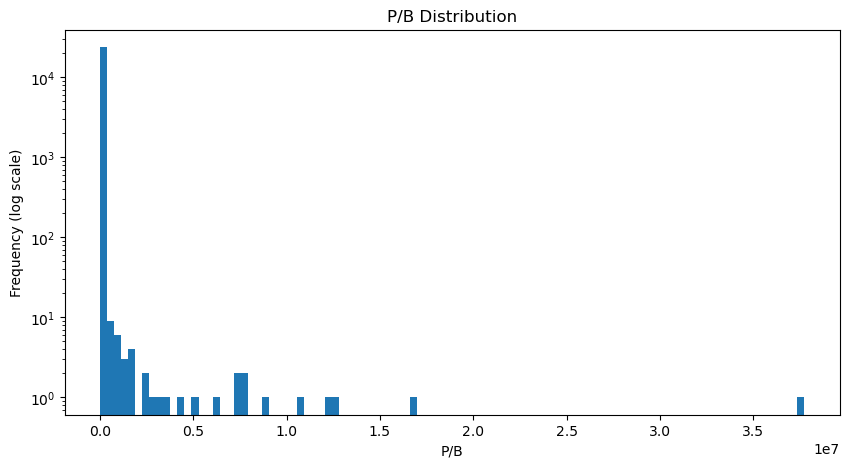

In [21]:
plt.figure(figsize=(10, 5))
plt.hist(weights_at_E["pb"], bins=100)
plt.yscale("log")
plt.title("P/B Distribution")
plt.xlabel("P/B")
plt.ylabel("Frequency (log scale)")
plt.show()

### 10. Universe size over time

In [22]:
universe_size = (
    signals_at_T.groupby("signal_date")["ticker"]
    .nunique()
    .reset_index(name="n_universe")
)

universe_size.head()

,signal_date,n_universe
0,2006-02-28,1000
1,2006-03-31,999
2,2006-04-28,999
3,2006-05-31,998
4,2006-06-30,1000


In [23]:
universe_size["n_universe"].describe()

count     238.000000
mean      998.516807
std         1.454562
min       993.000000
25%       998.000000
50%       999.000000
75%      1000.000000
max      1000.000000
Name: n_universe, dtype: float64

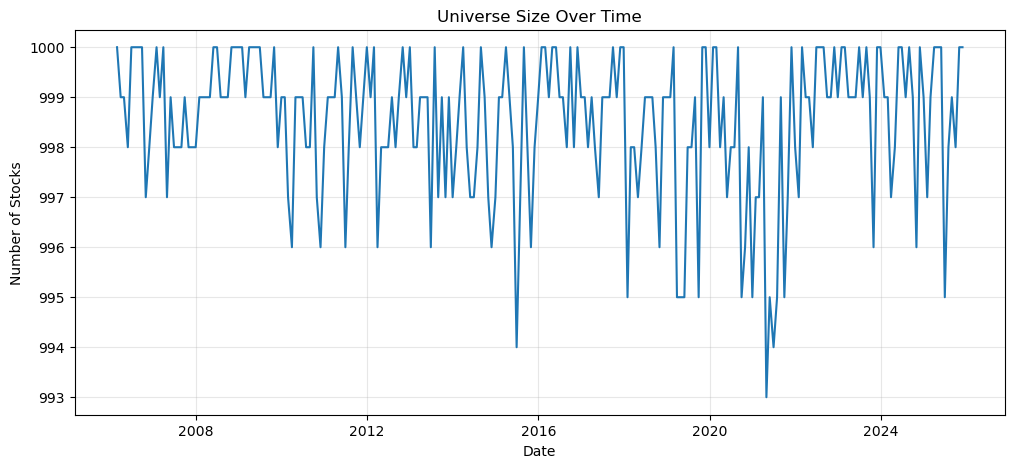

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(universe_size["signal_date"], universe_size["n_universe"])
plt.title("Universe Size Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Stocks")
plt.grid(True, alpha=0.3)
plt.show()

### 11. Portfolio breadth over time

In [25]:
breadth = (
    asset_returns
    .groupby(["signal_date", "side"])["ticker"]
    .nunique()
    .unstack()
    .reset_index()
    .rename(columns={"long": "n_long", "short": "n_short"})
)

breadth.head()

side,signal_date,n_long,n_short
0,2006-02-28,50,50
1,2006-03-31,50,50
2,2006-04-28,50,50
3,2006-05-31,50,50
4,2006-06-30,50,50


In [26]:
breadth[["n_long", "n_short"]].describe()

side,n_long,n_short
count,238.000000,238.0
mean,49.987395,50.0
std,0.111797,0.0
min,49.000000,50.0
25%,50.000000,50.0
50%,50.000000,50.0
75%,50.000000,50.0
max,50.000000,50.0


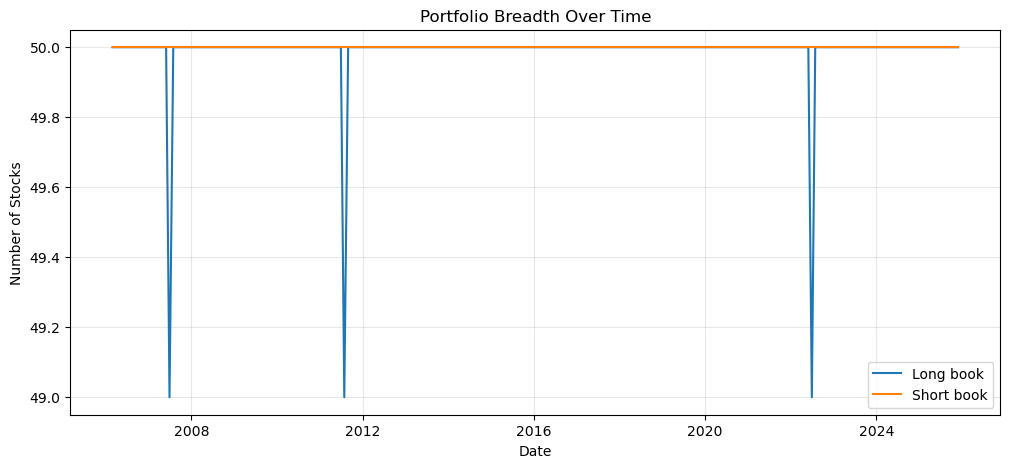

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(breadth["signal_date"], breadth["n_long"], label="Long book")
plt.plot(breadth["signal_date"], breadth["n_short"], label="Short book")
plt.title("Portfolio Breadth Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Stocks")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 12. Long vs short composition

In [28]:
factor_summary_by_side = (
    weights_at_E.groupby("side")[["market_cap", "pb", "mom_1m"]]
    .mean()
)

factor_summary_by_side

,market_cap,pb,mom_1m
side,,,
long,3.105834e+09,1.389838,0.112544
short,4.273945e+11,17539.656692,-0.077642


In [29]:
factor_check = (
    weights_at_E
    .groupby(["signal_date", "side"])
    .agg({
        "market_cap": "mean",
        "pb": "mean",
        "mom_1m": "mean"
    })
    .reset_index()
    .pivot(index="signal_date", columns="side")
)

factor_check.columns = ["_".join(col) for col in factor_check.columns]
factor_check = factor_check.reset_index()

factor_check.head()

,signal_date,market_cap_long,market_cap_short,pb_long,pb_short,mom_1m_long,mom_1m_short
0,2006-02-28,7.391860e+08,4.272903e+10,1.644919,66.866578,0.094098,-0.105445
1,2006-03-31,6.917869e+08,3.853834e+10,1.673402,109.506567,0.122520,-0.056483
2,2006-04-28,1.027231e+09,3.473140e+10,1.617369,113.842711,0.115296,-0.065146
3,2006-05-31,8.845593e+08,2.729453e+10,1.567484,256.399783,0.049429,-0.132998
4,2006-06-30,7.470428e+08,3.176746e+10,1.513213,175.067435,0.090191,-0.065006


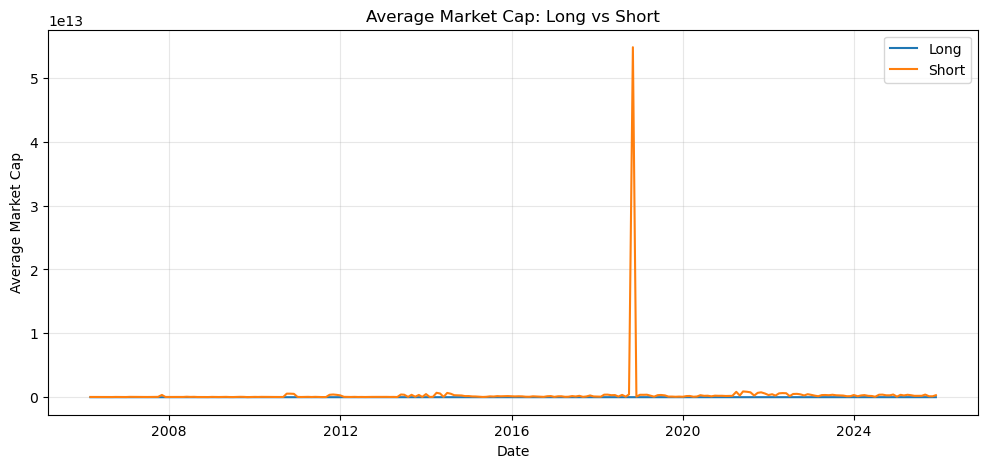

In [30]:
plt.figure(figsize=(12, 5))
plt.plot(factor_check["signal_date"], factor_check["market_cap_long"], label="Long")
plt.plot(factor_check["signal_date"], factor_check["market_cap_short"], label="Short")
plt.title("Average Market Cap: Long vs Short")
plt.xlabel("Date")
plt.ylabel("Average Market Cap")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

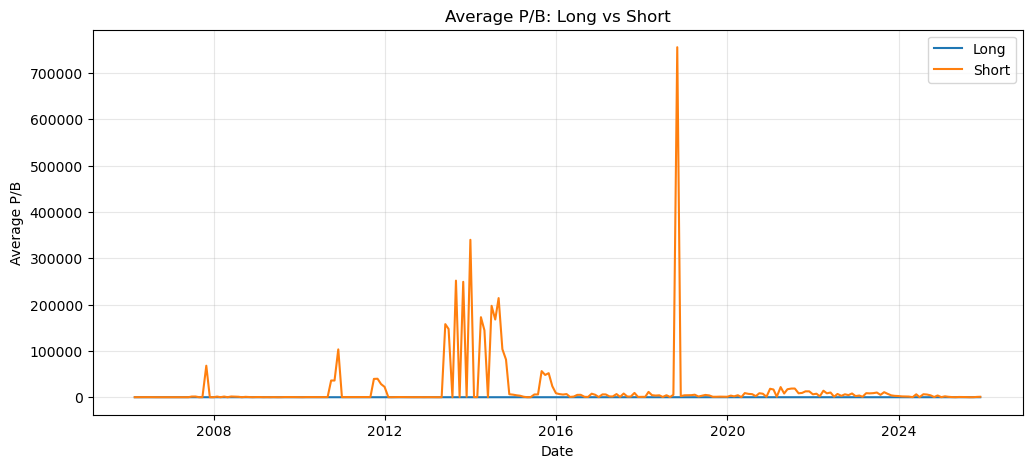

In [31]:
plt.figure(figsize=(12, 5))
plt.plot(factor_check["signal_date"], factor_check["pb_long"], label="Long")
plt.plot(factor_check["signal_date"], factor_check["pb_short"], label="Short")
plt.title("Average P/B: Long vs Short")
plt.xlabel("Date")
plt.ylabel("Average P/B")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

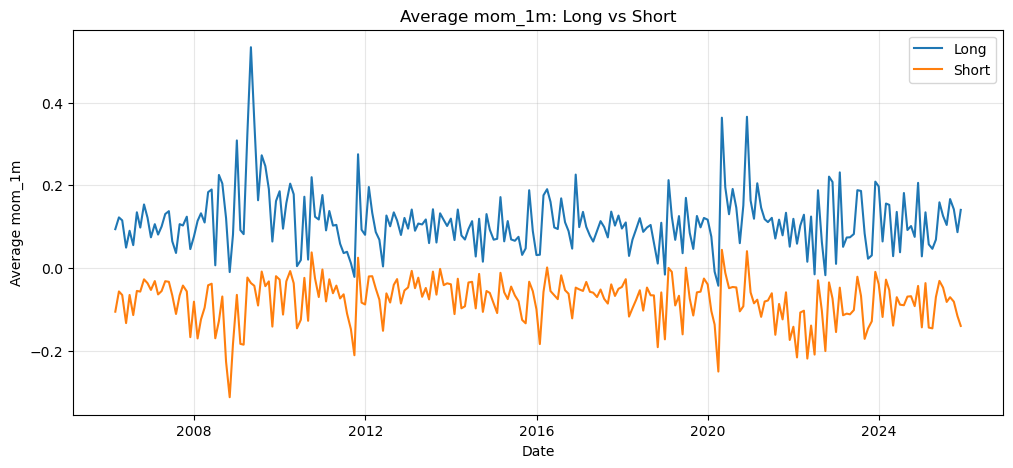

In [32]:
plt.figure(figsize=(12, 5))
plt.plot(factor_check["signal_date"], factor_check["mom_1m_long"], label="Long")
plt.plot(factor_check["signal_date"], factor_check["mom_1m_short"], label="Short")
plt.title("Average mom_1m: Long vs Short")
plt.xlabel("Date")
plt.ylabel("Average mom_1m")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 13. Benchmark comparison vs S&P 500

In [33]:
sp = yf.download(
    "^GSPC",
    start="1996-01-01",
    end="2026-01-01",
    progress=False,
    auto_adjust=False
)

sp_price = sp[("Adj Close", "^GSPC")]

sp_monthly = (
    sp_price
    .resample("ME")
    .last()
    .pct_change()
    .dropna()
    .to_frame("sp_return")
    .reset_index()
    .rename(columns={"Date": "signal_date"})
)

sp_monthly["signal_date"] = pd.to_datetime(sp_monthly["signal_date"])

sp_monthly.head()

,signal_date,sp_return
0,1996-02-29,0.006934
1,1996-03-31,0.007917
2,1996-04-30,0.013431
3,1996-05-31,0.022853
4,1996-06-30,0.002257


In [34]:
portfolio_returns["signal_date"] = pd.to_datetime(portfolio_returns["signal_date"])
portfolio_returns.head()

,signal_date,execution_date,next_execution_date,portfolio_return
0,2006-02-28,2006-03-01,2006-04-03,0.018233
1,2006-03-31,2006-04-03,2006-05-01,0.012567
2,2006-04-28,2006-05-01,2006-06-01,0.008021
3,2006-05-31,2006-06-01,2006-07-03,0.008289
4,2006-06-30,2006-07-03,2006-08-01,0.002550


In [35]:
portfolio_returns = portfolio_returns.sort_values("signal_date").reset_index(drop=True)
sp_monthly = sp_monthly.sort_values("signal_date").reset_index(drop=True)

In [36]:
merged = pd.merge(
    portfolio_returns,
    sp_monthly,
    on="signal_date",
    how="inner"
)

print(merged.shape)
merged.head()

(168, 5)


,signal_date,execution_date,next_execution_date,portfolio_return,sp_return
0,2006-02-28,2006-03-01,2006-04-03,0.018233,0.000453
1,2006-03-31,2006-04-03,2006-05-01,0.012567,0.011096
2,2006-05-31,2006-06-01,2006-07-03,0.008289,-0.030917
3,2006-06-30,2006-07-03,2006-08-01,0.002550,0.000087
4,2006-07-31,2006-08-01,2006-09-01,-0.003830,0.005086


In [37]:
merged["cum_modified_ff"] = (1 + merged["portfolio_return"]).cumprod()
merged["cum_sp"] = (1 + merged["sp_return"]).cumprod()

merged[["signal_date", "portfolio_return", "sp_return", "cum_modified_ff", "cum_sp"]].head()

,signal_date,portfolio_return,sp_return,cum_modified_ff,cum_sp
0,2006-02-28,0.018233,0.000453,1.018233,1.000453
1,2006-03-31,0.012567,0.011096,1.031029,1.011554
2,2006-05-31,0.008289,-0.030917,1.039575,0.980280
3,2006-06-30,0.002550,0.000087,1.042226,0.980365
4,2006-07-31,-0.003830,0.005086,1.038235,0.985351


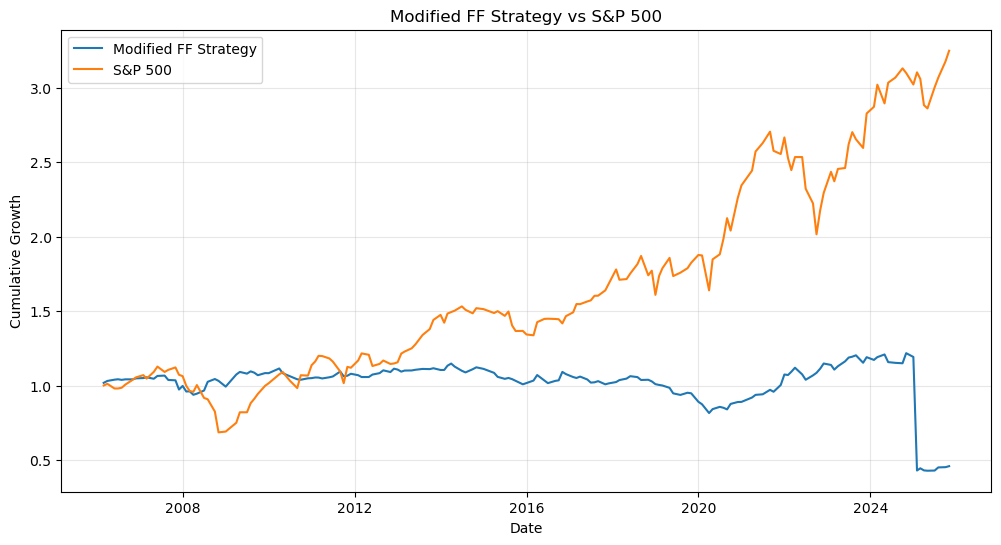

In [38]:
plt.figure(figsize=(12, 6))
plt.plot(merged["signal_date"], merged["cum_modified_ff"], label="Modified FF Strategy")
plt.plot(merged["signal_date"], merged["cum_sp"], label="S&P 500")
plt.title("Modified FF Strategy vs S&P 500")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [39]:
def annualized_sharpe(monthly_returns):
    monthly_returns = monthly_returns.dropna()
    return monthly_returns.mean() / monthly_returns.std() * np.sqrt(12)

print("Modified FF Sharpe:", annualized_sharpe(merged["portfolio_return"]))
print("S&P 500 Sharpe:", annualized_sharpe(merged["sp_return"]))

Modified FF Sharpe: -0.1335823767755534
S&P 500 Sharpe: 0.6271436596297293


In [40]:
def max_drawdown(return_series):
    cum = (1 + return_series.fillna(0)).cumprod()
    roll_max = cum.cummax()
    drawdown = cum / roll_max - 1
    return drawdown.min()

def performance_summary(return_series):
    return pd.Series({
        "mean_monthly": return_series.mean(),
        "vol_monthly": return_series.std(),
        "ann_sharpe": annualized_sharpe(return_series),
        "positive_month_pct": (return_series > 0).mean(),
        "max_drawdown": max_drawdown(return_series),
    })

benchmark_summary = pd.DataFrame({
    "Modified FF Strategy": performance_summary(merged["portfolio_return"]),
    "S&P 500": performance_summary(merged["sp_return"]),
}).T

benchmark_summary

,mean_monthly,vol_monthly,ann_sharpe,positive_month_pct,max_drawdown
Modified FF Strategy,-0.002106,0.054623,-0.133582,0.541667,-0.648474
S&P 500,0.008028,0.044342,0.627144,0.636905,-0.391858


### 14. Turnover

In [41]:
membership_sets = (
    weights_at_E.groupby("signal_date")["ticker"]
    .apply(set)
    .reset_index(name="ticker_set")
    .sort_values("signal_date")
    .reset_index(drop=True)
)

turnover_records = []
for i in range(1, len(membership_sets)):
    prev_set = membership_sets.loc[i - 1, "ticker_set"]
    curr_set = membership_sets.loc[i, "ticker_set"]

    entered = len(curr_set - prev_set)
    exited = len(prev_set - curr_set)
    union_n = len(curr_set | prev_set)
    prev_n = len(prev_set)

    turnover_records.append({
        "signal_date": membership_sets.loc[i, "signal_date"],
        "entered": entered,
        "exited": exited,
        "turnover_rate_vs_prev": (entered + exited) / prev_n if prev_n > 0 else np.nan,
        "jaccard_similarity": len(curr_set & prev_set) / union_n if union_n > 0 else np.nan,
    })

turnover_df = pd.DataFrame(turnover_records)
turnover_df.head()

,signal_date,entered,exited,turnover_rate_vs_prev,jaccard_similarity
0,2006-03-31,61,61,1.22,0.242236
1,2006-04-28,64,64,1.28,0.219512
2,2006-05-31,74,74,1.48,0.149425
3,2006-06-30,64,64,1.28,0.219512
4,2006-07-31,71,71,1.42,0.169591


In [42]:
turnover_df.describe()

,signal_date,entered,exited,turnover_rate_vs_prev,jaccard_similarity
count,237,237.000000,237.000000,237.000000,237.000000
mean,2016-01-29 15:23:32.658227968,68.443038,68.443038,1.369044,0.188976
min,2006-03-31 00:00:00,51.000000,51.000000,1.020000,0.086957
25%,2011-02-28 00:00:00,64.000000,64.000000,1.280000,0.156069
50%,2016-01-29 00:00:00,69.000000,69.000000,1.380000,0.183432
75%,2020-12-31 00:00:00,73.000000,73.000000,1.460000,0.219512
max,2025-11-28 00:00:00,84.000000,84.000000,1.680000,0.324503
std,NaN,6.366784,6.350791,0.127291,0.045074


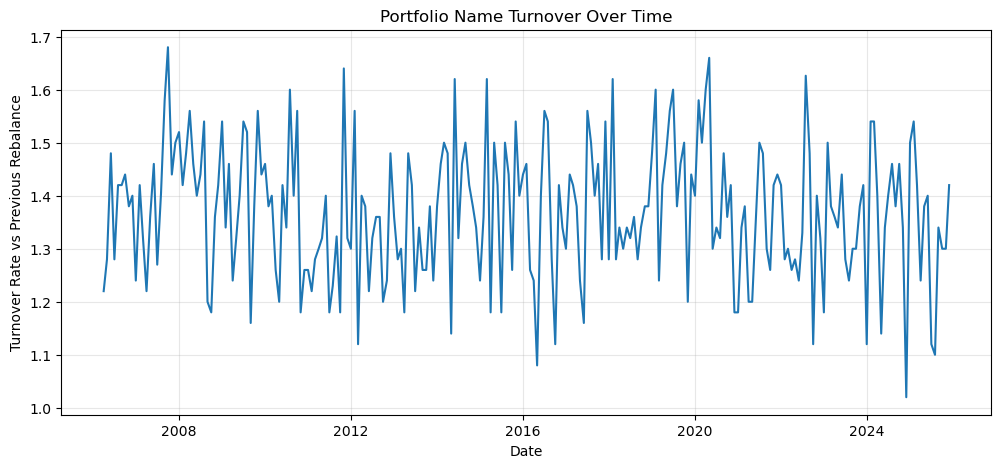

In [43]:
plt.figure(figsize=(12, 5))
plt.plot(turnover_df["signal_date"], turnover_df["turnover_rate_vs_prev"])
plt.title("Portfolio Name Turnover Over Time")
plt.xlabel("Date")
plt.ylabel("Turnover Rate vs Previous Rebalance")
plt.grid(True, alpha=0.3)
plt.show()

In [44]:
side_sets = (
    weights_at_E.groupby(["signal_date", "side"])["ticker"]
    .apply(set)
    .reset_index(name="ticker_set")
)

long_sets = (
    side_sets[side_sets["side"] == "long"][["signal_date", "ticker_set"]]
    .sort_values("signal_date")
    .reset_index(drop=True)
)

short_sets = (
    side_sets[side_sets["side"] == "short"][["signal_date", "ticker_set"]]
    .sort_values("signal_date")
    .reset_index(drop=True)
)

In [45]:
def compute_turnover_from_sets(df_sets: pd.DataFrame, label: str) -> pd.DataFrame:
    records = []
    for i in range(1, len(df_sets)):
        prev_set = df_sets.loc[i - 1, "ticker_set"]
        curr_set = df_sets.loc[i, "ticker_set"]
        prev_n = len(prev_set)
        union_n = len(curr_set | prev_set)

        records.append({
            "signal_date": df_sets.loc[i, "signal_date"],
            f"{label}_turnover": (len(curr_set - prev_set) + len(prev_set - curr_set)) / prev_n if prev_n > 0 else np.nan,
            f"{label}_jaccard": len(curr_set & prev_set) / union_n if union_n > 0 else np.nan,
        })
    return pd.DataFrame(records)

long_turnover = compute_turnover_from_sets(long_sets, "long")
short_turnover = compute_turnover_from_sets(short_sets, "short")

long_turnover.head(), short_turnover.head()

(  signal_date  long_turnover  long_jaccard
 0  2006-03-31           1.20      0.250000
 1  2006-04-28           1.44      0.162791
 2  2006-05-31           1.68      0.086957
 3  2006-06-30           1.32      0.204819
 4  2006-07-31           1.40      0.176471,
   signal_date  short_turnover  short_jaccard
 0  2006-03-31            1.24       0.234568
 1  2006-04-28            1.12       0.282051
 2  2006-05-31            1.28       0.219512
 3  2006-06-30            1.24       0.234568
 4  2006-07-31            1.44       0.162791)

In [46]:
turnover_side = long_turnover.merge(short_turnover, on="signal_date", how="inner")
turnover_side.head()

,signal_date,long_turnover,long_jaccard,short_turnover,short_jaccard
0,2006-03-31,1.20,0.250000,1.24,0.234568
1,2006-04-28,1.44,0.162791,1.12,0.282051
2,2006-05-31,1.68,0.086957,1.28,0.219512
3,2006-06-30,1.32,0.204819,1.24,0.234568
4,2006-07-31,1.40,0.176471,1.44,0.162791


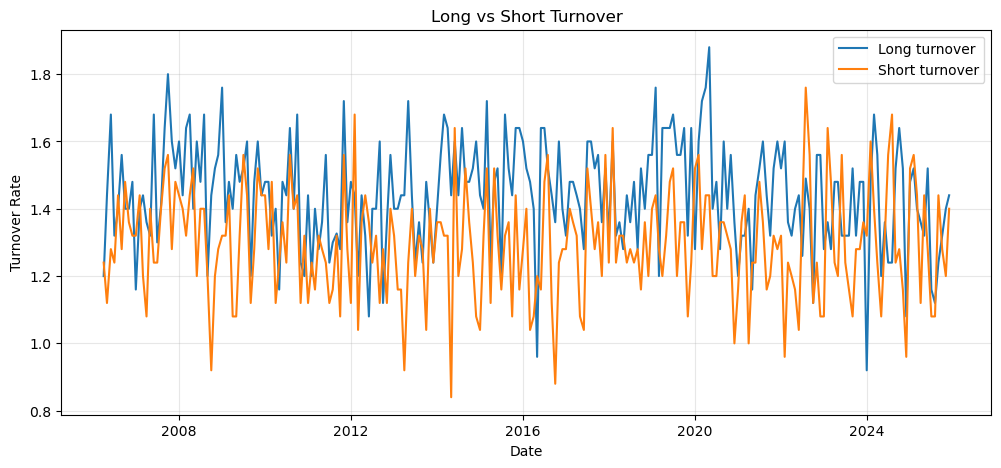

In [47]:
plt.figure(figsize=(12, 5))
plt.plot(turnover_side["signal_date"], turnover_side["long_turnover"], label="Long turnover")
plt.plot(turnover_side["signal_date"], turnover_side["short_turnover"], label="Short turnover")
plt.title("Long vs Short Turnover")
plt.xlabel("Date")
plt.ylabel("Turnover Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 15. A compact text summary cell for every model

In [48]:
print("=== MODEL SUMMARY ===")
print(f"Net annualized Sharpe: {annualized_sharpe(ls_monthly['portfolio_return_rebuilt']):.4f}")
print(f"Long annualized Sharpe: {annualized_sharpe(ls_monthly['long_return']):.4f}")
print(f"Short annualized Sharpe: {annualized_sharpe(ls_monthly['short_return']):.4f}")
print(f"Long-short correlation: {ls_monthly['long_return'].corr(ls_monthly['short_return']):.4f}")
print(f"Max drawdown: {max_drawdown(ls_monthly['portfolio_return_rebuilt']):.4f}")
print(f"Average universe size: {universe_size['n_universe'].mean():.2f}")
print(f"Average long breadth: {breadth['n_long'].mean():.2f}")
print(f"Average short breadth: {breadth['n_short'].mean():.2f}")

=== MODEL SUMMARY ===
Net annualized Sharpe: -0.1494
Long annualized Sharpe: 0.4546
Short annualized Sharpe: -0.4399
Long-short correlation: -0.4444
Max drawdown: -0.6713
Average universe size: 998.52
Average long breadth: 49.99
Average short breadth: 50.00
